In [3]:
# Install face recognition library
!pip install -q face_recognition

import face_recognition
import cv2
import pickle
import os
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, time
from google.colab import drive, files
from IPython.display import display

print("✅ Libraries successfully imported!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ Libraries successfully imported!


In [4]:
# --- 1. Connect to Drive ---
drive.mount('/content/drive')
db_path = '/content/drive/MyDrive/model/student_database.pkl'

# --- 2. Load Existing Database or Create New ---
if os.path.exists(db_path):
    with open(db_path, 'rb') as f:
        database = pickle.load(f)
    known_face_encodings = database['encodings']
    known_names = database['names']
    print(f"Loaded existing database. Current enrolled students: {len(known_names)}")
else:
    known_face_encodings = []
    known_names = []
    print("No database found. Starting a brand new one!")

# --- 3. Capture & Process Student Photo ---
print("\n--- Capturing Student Photo ---")
print("Upload ONE clear selfie / photo of the student.")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

student_name = input("👉 Enter Student Name and Roll Number (e.g., Priya - Roll 12): ")

img = face_recognition.load_image_file(filename)
encodings = face_recognition.face_encodings(img)

if len(encodings) > 0:
    known_face_encodings.append(encodings[0])
    known_names.append(student_name)

    # Save updated database
    os.makedirs(os.path.dirname(db_path), exist_ok=True)
    with open(db_path, 'wb') as f:
        pickle.dump({'encodings': known_face_encodings, 'names': known_names}, f)

    print(f"\n🎉 SUCCESS! {student_name}'s Face DNA has been securely saved to Drive!")
else:
    print("\n🚨 ERROR: No face found in the photo. Please try a clearer selfie!")

Mounted at /content/drive
Loaded existing database. Current enrolled students: 1

--- Capturing Student Photo ---
Upload ONE clear selfie / photo of the student.


Saving WhatsApp Image 2026-07-29 at 10.29.07 AM.jpeg to WhatsApp Image 2026-07-29 at 10.29.07 AM.jpeg
👉 Enter Student Name and Roll Number (e.g., Priya - Roll 12): sheetal,rollno-241315

🎉 SUCCESS! sheetal,rollno-241315's Face DNA has been securely saved to Drive!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Database Loaded! Found 2 registered students.

--- Upload Group Photo for Attendance ---


Saving WhatsApp Image 2026-08-02 at 12.00.25 PM.jpeg to WhatsApp Image 2026-08-02 at 12.00.25 PM.jpeg

📸 AI detected 14 faces in the photo.

--- Attendance Table Summary ---


,Date,Time,Name / Roll No,Status


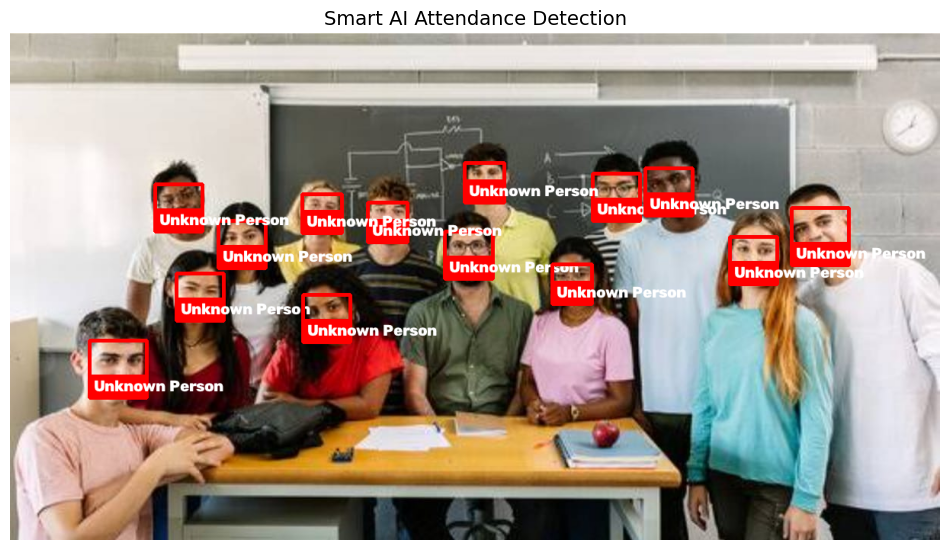

In [5]:
# --- 1. Load Database & Setup Paths ---
drive.mount('/content/drive')
db_path = '/content/drive/MyDrive/model/student_database.pkl'
csv_path = '/content/drive/MyDrive/model/attendance_log.csv'

if os.path.exists(db_path):
    with open(db_path, 'rb') as f:
        database = pickle.load(f)
    known_face_encodings = database['encodings']
    known_names = database['names']
    print(f"✅ Database Loaded! Found {len(known_names)} registered students.")
else:
    raise ValueError("🚨 ERROR: Database not found! Please register students first.")

# --- 2. Upload Group Photo ---
print("\n--- Upload Group Photo for Attendance ---")
group_upload = files.upload()
group_filename = list(group_upload.keys())[0]

group_img = face_recognition.load_image_file(group_filename)
face_locations = face_recognition.face_locations(group_img)
face_encodings = face_recognition.face_encodings(group_img, face_locations)

print(f"\n📸 AI detected {len(face_locations)} faces in the photo.")

recognized_students = set()
group_img_bgr = cv2.cvtColor(group_img, cv2.COLOR_RGB2BGR)

# --- 3. Matching & Bounding Box ---
for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):
    matches = face_recognition.compare_faces(known_face_encodings, face_encoding, tolerance=0.5)
    name = "Unknown Person"
    color = (0, 0, 255) # Red for Unknown

    if True in matches:
        first_match_index = matches.index(True)
        name = known_names[first_match_index]
        color = (0, 255, 0) # Green for Recognized
        recognized_students.add(name)

    # Draw Boxes
    cv2.rectangle(group_img_bgr, (left, top), (right, bottom), color, 3)
    cv2.rectangle(group_img_bgr, (left, bottom - 30), (right, bottom), color, cv2.FILLED)
    cv2.putText(group_img_bgr, name, (left + 6, bottom - 8), cv2.FONT_HERSHEY_DUPLEX, 0.7, (255, 255, 255), 2)

# --- 4. Attendance Timing & Anti-Duplicate Logging ---
now = datetime.now()
date_str = now.strftime("%Y-%m-%d")
time_str = now.strftime("%H:%M:%S")

# Time window (9:30 AM to 1:30 PM)
start_time = time(9, 30)
end_time = time(13, 30)
current_time = now.time()

status = "Present" if start_time <= current_time <= end_time else "Late / Out of Window"

# Load or create CSV
if os.path.exists(csv_path):
    df_existing = pd.read_csv(csv_path)
else:
    df_existing = pd.DataFrame(columns=["Date", "Time", "Name / Roll No", "Status"])

new_records = []
for student in recognized_students:
    # Check duplicate entry for today
    already_marked = not df_existing[(df_existing['Date'] == date_str) & (df_existing['Name / Roll No'] == student)].empty

    if not already_marked:
        new_records.append({
            "Date": date_str,
            "Time": time_str,
            "Name / Roll No": student,
            "Status": status
        })
    else:
        print(f"ℹ️ {student} ki attendance aaj already mark ho chuki hai. Skipping duplicate.")

if new_records:
    df_new = pd.DataFrame(new_records)
    df_final = pd.concat([df_existing, df_new], ignore_index=True)
    df_final.to_csv(csv_path, index=False)
    print(f"✅ Attendance updated in CSV!")
else:
    df_final = df_existing

# --- 5. Visual Summary & Charts ---
print("\n--- Attendance Table Summary ---")
display(df_final.tail(10))

# Display Image Result
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(group_img_bgr, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Smart AI Attendance Detection", fontsize=14)
plt.show()

# Display Attendance Graph
if not df_final.empty:
    plt.figure(figsize=(6, 4))
    df_final['Status'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
    plt.title(f"Attendance Status Summary ({date_str})")
    plt.xlabel("Status")
    plt.ylabel("Count")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()